In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("creditcard.csv")

df.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

print(df['Class'].value_counts())

(690, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB
None
         CustomerID          A1          A2          A3          A4  \
count  6.900000e+02

In [4]:
print(df.isnull().sum())

CustomerID    0
A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
A8            0
A9            0
A10           0
A11           0
A12           0
A13           0
A14           0
Class         0
dtype: int64


In [ ]:
df = df.drop_duplicates()
print(df.shape)

(690, 16)


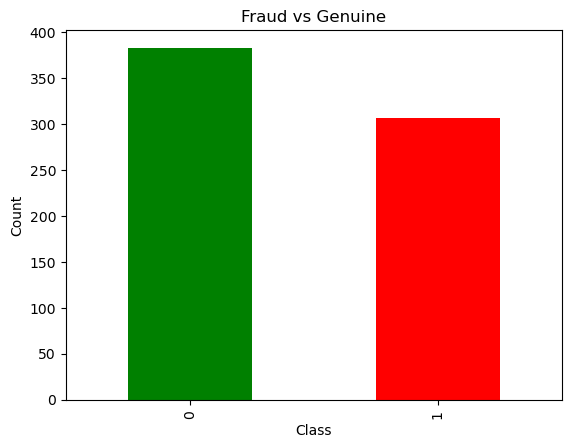

In [6]:
df['Class'].value_counts().plot(
    kind='bar',
    color=['green','red']
)

plt.title("Fraud vs Genuine")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

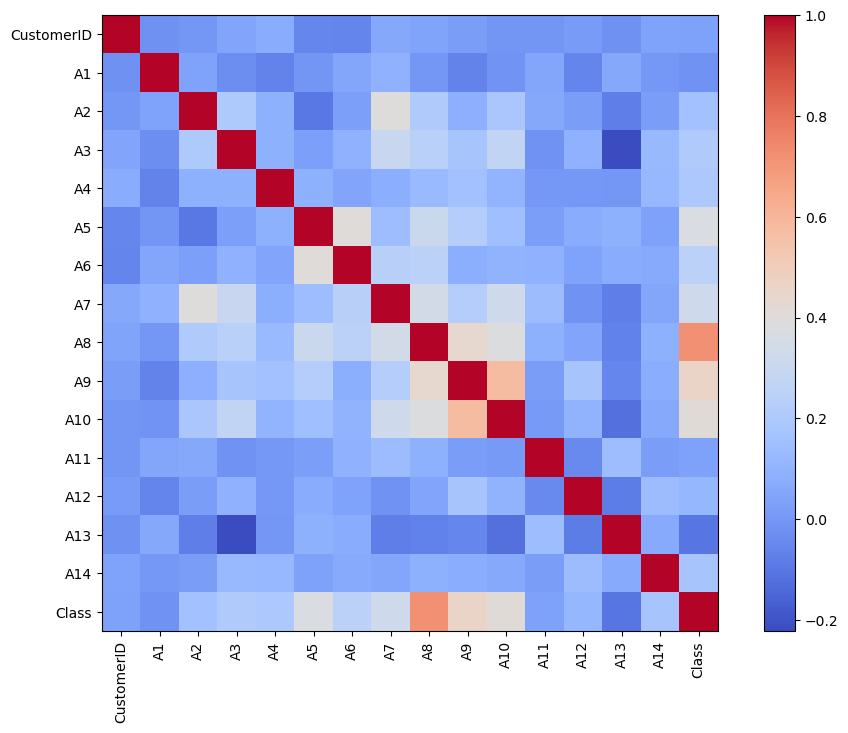

In [ ]:
plt.figure(figsize=(12,8))
plt.imshow(df.corr(), cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.show()

In [ ]:
X = df.drop(["CustomerID","Class"], axis=1)
y = df["Class"]
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print(pd.Series(y).value_counts())

Class
0    383
1    383
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
prediction = lr.predict(X_test)

print(classification_report(y_test,prediction))
print("Accuracy :",accuracy_score(y_test,prediction))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89        77
           1       0.89      0.91      0.90        77

    accuracy                           0.90       154
   macro avg       0.90      0.90      0.90       154
weighted avg       0.90      0.90      0.90       154

Accuracy : 0.8961038961038961


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)
rf_prediction = rf.predict(X_test)

print(classification_report(y_test,rf_prediction))
print("Accuracy :",accuracy_score(y_test,rf_prediction))

              precision    recall  f1-score   support

           0       0.91      0.90      0.90        77
           1       0.90      0.91      0.90        77

    accuracy                           0.90       154
   macro avg       0.90      0.90      0.90       154
weighted avg       0.90      0.90      0.90       154

Accuracy : 0.9025974025974026


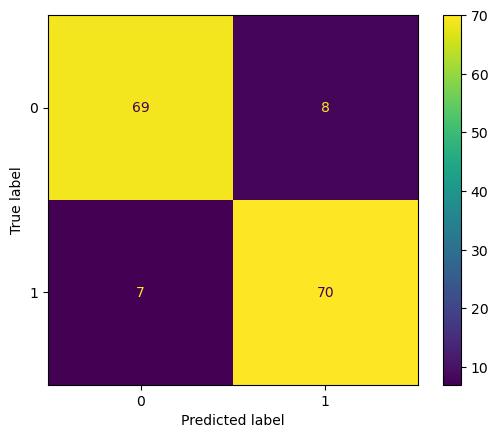

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_prediction
)

plt.show()

In [ ]:
prob = rf.predict_proba(X_test)[:,1]
print("ROC AUC :",roc_auc_score(y_test,prob))

ROC AUC : 0.9626412548490471


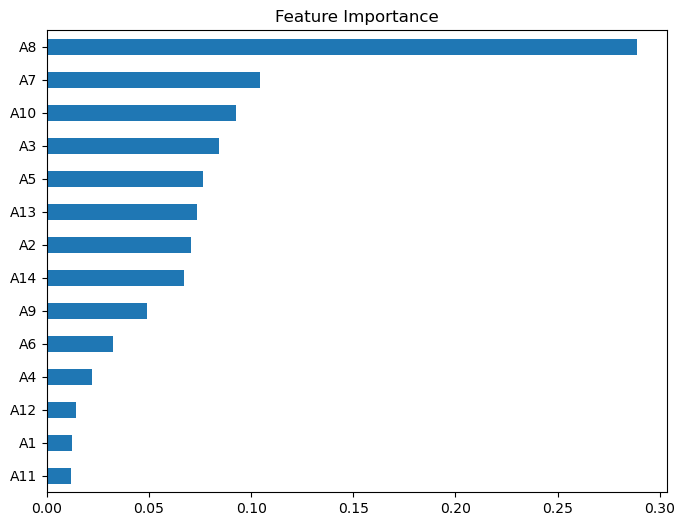

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=df.drop(["CustomerID","Class"],axis=1).columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.show()

In [ ]:
iso = IsolationForest(
    contamination=0.1,
    random_state=42
)

iso.fit(X_train)
pred = iso.predict(X_test)
print(pd.Series(pred).value_counts())

 1    140
-1     14
Name: count, dtype: int64


In [ ]:
import joblib
joblib.dump(rf,"fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [18]:
model = joblib.load("fraud_detection_model.pkl")